# 03 — Model Training

This notebook covers all Day 3 model training work:
1. Linear regression baseline
2. Random Forest with hyperparameter tuning
3. Gradient Boosting (XGBoost/LightGBM) with hyperparameter search

**Goal:** Train ML models that outperform the Riegel and VDOT formula baselines established in notebook 02.  
**Data:** Engineered features from `data/processed/train.parquet` and `data/processed/test.parquet`.

## Setup

In [35]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from src.evaluate import regression_metrics, comparison_table

sns.set_theme(style='whitegrid')
%matplotlib inline

## Load train/test data

In [2]:
train = pd.read_parquet('../data/processed/train.parquet')
test = pd.read_parquet('../data/processed/test.parquet')

print(f'Train: {train.shape}')
print(f'Test:  {test.shape}')

Train: (388, 14)
Test:  (97, 14)


In [40]:
# Define feature columns and target
# Adjust these to match whatever you saved in notebook 02
target_col = 'mf_ti_adj'  # marathon finish time (minutes)

feature_cols = [
    "age",
    "bmi",
    "female",
    "injury",
    "footwear",
    "mh_ti_adj_final",
    "mh_ti_adj_imputed_flag",
    "tempo",
    "sprint",
    "typical",
    "mean_vdot",
    "vdot_consistency",
]

X_train = train[feature_cols]
y_train = train[target_col]
X_test = test[feature_cols]
y_test = test[target_col]


print(f'Features: {len(feature_cols)}')
print(f'Training samples: {len(X_train)}')
print(f'Test samples: {len(X_test)}')

Features: 12
Training samples: 388
Test samples: 97


## Collect baseline results from notebook 02

Pull in the Riegel and VDOT metrics so we can build a running comparison table.

In [44]:
# Paste your Riegel and VDOT baseline metrics from notebook 02 here
results = {
    'Riegel':  {'MAE': 15.53, 'RMSE': 20.89, 'MAPE': 6.53, 'R2': 0.78},
    'VDOT':    {'MAE': 16.18, 'RMSE': 21.70, 'MAPE': 6.75, 'R2': 0.77},
}

---

## 1. Linear Regression

The simplest ML model. If this can't beat Riegel, the features probably aren't informative enough.

In [47]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
results['Linear Regression'] = regression_metrics(y_test, y_pred_lr)
results['Linear Regression']

{'MAE': np.float64(11.04),
 'RMSE': np.float64(14.81),
 'MAPE': np.float64(4.62),
 'R2': np.float64(0.8879)}

### Linear regression results

| Model | MAE (min) | RMSE (min) | MAPE (%) | R² |
|-------|-----------|------------|----------|------|
| Riegel baseline | 15.53 | 20.89 | 6.53 | 0.78 |
| VDOT baseline | 16.18 | 21.70 | 6.75 | 0.77 |
| LR — VDOT + half marathon | 11.04 | 14.81 | 4.62 | 0.8879 |
| LR — VDOT only | 12.31 | 16.52 | 5.18 | 0.8606 |
| LR — half marathon only | 11.04 | 15.39 | 4.61 | 0.8790 |

Even a simple regression is significantly beats Riegel by 4.5 minutes (~30% improvement). Using half marathon alone basically does all the work. Adding VDOT improves RMSE by 0.6 and R2 by 1%, but thats marginal. In contrast, VDOT alone is worse than just using half marathon data, but despite that its still significantly better than just using VDOT or Riegel.

### Feature coefficients

Which features does linear regression lean on most when using VDOT and Half Marathon?

In [46]:
coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': lr.coef_
}).sort_values('coefficient', key=abs, ascending=False)

coef_df

print(coef_df.to_string(index=False))

               feature  coefficient
      vdot_consistency    18.616329
                female    -5.367727
                injury     3.284082
                 tempo     1.800336
              footwear     1.739863
       mh_ti_adj_final     1.578245
             mean_vdot    -1.298319
                sprint     1.252336
mh_ti_adj_imputed_flag     1.195400
                   bmi     0.873455
               typical    -0.190884
                   age    -0.150831


We have to be careful interpreting these values relative to eachother because none of them are on the same scale.

Vdot consistency has a super high value, but thats because most runners only have vdot consistency scores around 0.2. Female has a value of -5.4, which is saying that our model predicts that women run faster than men. This is counterintuitive. Our model cound be picking up something confounded with VDOT here, where women with the same VDOT as men perform better. Or this selection of data has a faster population of female runners than men. Now that I think about it, the violin plot for women was pretty bottom heavy. This model also says that older people run faster marathons, by a small margin. We could have a lot of faster older runners in this dataset, or vice versa. Age could also be confounded with VDOT in a similar way as female.

### Residual analysis

Patterns in residuals mean the model is systematically wrong for certain runners.

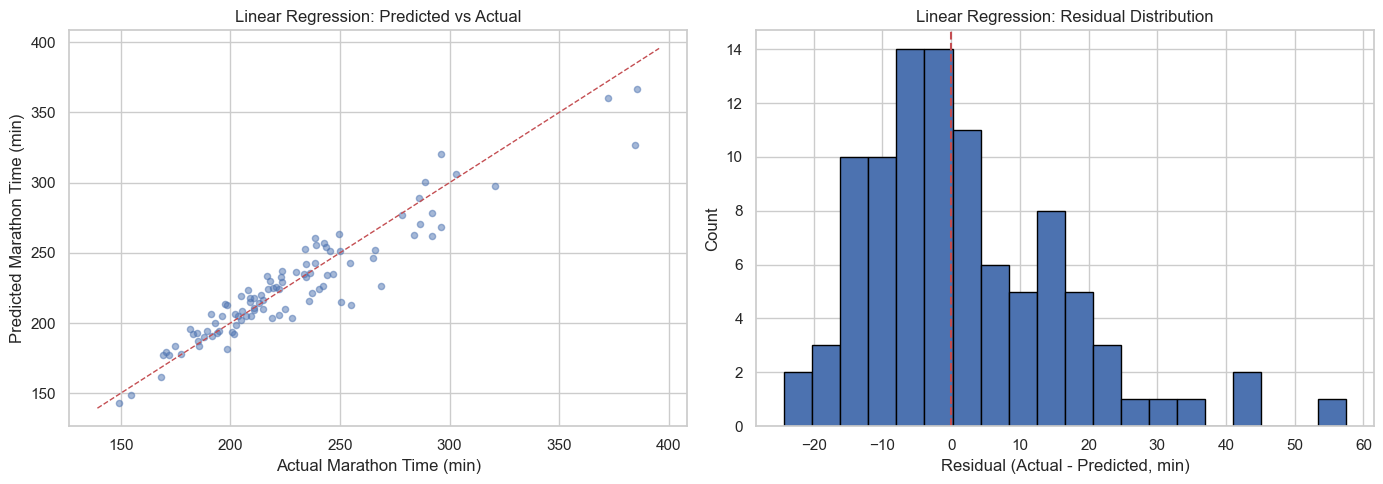

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs actual
axes[0].scatter(y_test, y_pred_lr, alpha=0.5, s=20)
lims = [y_test.min() - 10, y_test.max() + 10]
axes[0].plot(lims, lims, 'r--', linewidth=1)
axes[0].set_xlabel('Actual Marathon Time (min)')
axes[0].set_ylabel('Predicted Marathon Time (min)')
axes[0].set_title('Linear Regression: Predicted vs Actual')

# Residual histogram
residuals_lr = y_test - y_pred_lr
axes[1].hist(residuals_lr, bins=20, edgecolor='black')
axes[1].axvline(0, color='r', linestyle='--')
axes[1].set_xlabel('Residual (Actual - Predicted, min)')
axes[1].set_ylabel('Count')
axes[1].set_title('Linear Regression: Residual Distribution')

plt.tight_layout()
plt.savefig('../results/figures/lr_diagnostics.png', dpi=150)
plt.show()

Our regression model tends to overpredict for runners in the faster band and underpredict for slower runners. We can also see from the histogram on the right that many runners are getting sub par residuals. Lots of runners are being overpredicted by 10 minutes or over, while some runners on the other end of the spectrum are getting their times underpredicted by 30 to 50 minutes. Our summary statistics definitely beat Riegel and VDOT, but there is still a lot of work to be done. 

The takeaway here is that this model works pretty well for runners in the 150-240 band, but outside of that range these predictions become useless. Regression is really limited here. It is also important to remember that we also have a data issue. During EDA we established that our dataset skews a bit on the faster end.

### Comparison so far

In [48]:
comparison_table(results)

                     MAE   RMSE  MAPE      R2
Model                                        
Riegel             15.53  20.89  6.53  0.7800
VDOT               16.18  21.70  6.75  0.7700
Linear Regression  11.04  14.81  4.62  0.8879


,MAE,RMSE,MAPE,R2
Model,,,,
Riegel,15.53,20.89,6.53,0.7800
VDOT,16.18,21.70,6.75,0.7700
Linear Regression,11.04,14.81,4.62,0.8879


Regardless, Linear Regression beats the baselines and gets us close to our goals. We already have a MAPE < 5% and a sub-15 minute RMSE. The ~30% improvement in RMSE is really impressive; our model has less issues with dramatically poor predictions than Riegel and VDOT. We also gained 10% R2, which is awesome. We are definitely improving predictive power, but we can do better. Time to explore other models.

---

## 2. Random Forest

Strong default for tabular data. Can capture non-linear relationships that linear regression misses.

In [49]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
results['Random Forest'] = regression_metrics(y_test, y_pred_rf)
results['Random Forest']

{'MAE': np.float64(10.64),
 'RMSE': np.float64(14.95),
 'MAPE': np.float64(4.39),
 'R2': np.float64(0.8858)}

### Feature importance

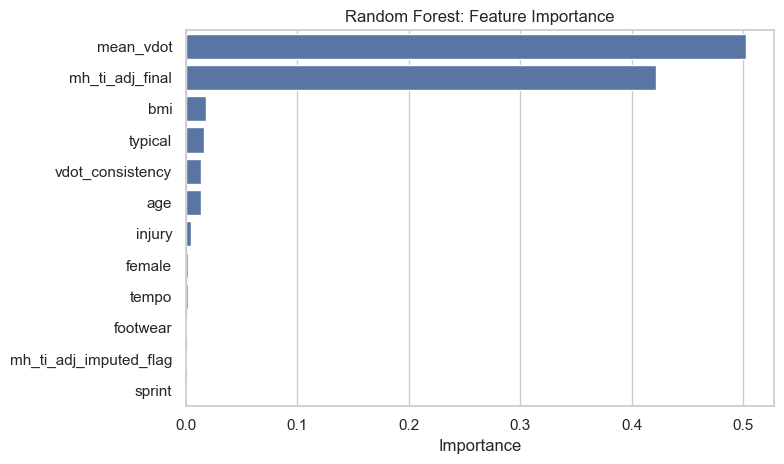

In [50]:
imp_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(8, max(4, len(feature_cols) * 0.4)))
sns.barplot(data=imp_df, x='importance', y='feature', ax=ax)
ax.set_title('Random Forest: Feature Importance')
ax.set_xlabel('Importance')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('../results/figures/rf_feature_importance.png', dpi=150)
plt.show()

### Hyperparameter tuning via cross-validation

Use `cross_val_score` on the training set (not test set) to select hyperparameters.

In [ ]:
# Grid of hyperparameters to try
param_grid = {
    'n_estimators': [50, 100, 200, 500],
    'max_depth': [None, 5, 10, 15],
}

cv_results = []

for n_est in param_grid['n_estimators']:
    for depth in param_grid['max_depth']:
        model = RandomForestRegressor(
            n_estimators=n_est,
            max_depth=depth,
            random_state=42
        )
        scores = cross_val_score(
            model, X_train, y_train,
            cv=5,
            scoring='neg_mean_absolute_error'
        )
        cv_results.append({
            'n_estimators': n_est,
            'max_depth': depth,
            'mean_mae': -scores.mean(),
            'std_mae': scores.std()
        })

cv_df = pd.DataFrame(cv_results).sort_values('mean_mae')
print(cv_df.to_string(index=False))

In [ ]:
# Retrain with best hyperparameters on full training set
best_row = cv_df.iloc[0]
print(f'Best params: n_estimators={int(best_row.n_estimators)}, max_depth={best_row.max_depth}')
print(f'CV MAE: {best_row.mean_mae:.2f} +/- {best_row.std_mae:.2f}')

rf_best = RandomForestRegressor(
    n_estimators=int(best_row.n_estimators),
    max_depth=best_row.max_depth if pd.notna(best_row.max_depth) else None,
    random_state=42
)
rf_best.fit(X_train, y_train)

y_pred_rf_best = rf_best.predict(X_test)
results['Random Forest (tuned)'] = regression_metrics(y_test, y_pred_rf_best)
results['Random Forest (tuned)']

### Does adding the Riegel prediction as a feature help?

Try training with and without the Riegel-predicted marathon time.

In [ ]:
# If you have a 'riegel_predicted' column in your features, test dropping it
# feature_cols_no_riegel = [c for c in feature_cols if c != 'riegel_predicted']
# rf_no_riegel = RandomForestRegressor(n_estimators=100, random_state=42)
# rf_no_riegel.fit(X_train[feature_cols_no_riegel], y_train)
# y_pred_no_riegel = rf_no_riegel.predict(X_test[feature_cols_no_riegel])
# print('With Riegel feature:', regression_metrics(y_test, y_pred_rf))
# print('Without Riegel feature:', regression_metrics(y_test, y_pred_no_riegel))

### Comparison so far

In [ ]:
comparison_table(results)

---

## 3. Gradient Boosting (XGBoost / LightGBM)

State-of-the-art for tabular prediction. This is what the Smyth group used in their research.

In [ ]:
# Pick one — uncomment whichever you have installed
from xgboost import XGBRegressor
# from lightgbm import LGBMRegressor

In [ ]:
# Default XGBoost as a quick check
xgb = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
results['XGBoost (default)'] = regression_metrics(y_test, y_pred_xgb)
results['XGBoost (default)']

### Hyperparameter search

In [ ]:
xgb_param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 5, 7],
}

xgb_cv_results = []

for lr in xgb_param_grid['learning_rate']:
    for n_est in xgb_param_grid['n_estimators']:
        for depth in xgb_param_grid['max_depth']:
            model = XGBRegressor(
                learning_rate=lr,
                n_estimators=n_est,
                max_depth=depth,
                random_state=42,
                verbosity=0
            )
            scores = cross_val_score(
                model, X_train, y_train,
                cv=5,
                scoring='neg_mean_absolute_error'
            )
            xgb_cv_results.append({
                'learning_rate': lr,
                'n_estimators': n_est,
                'max_depth': depth,
                'mean_mae': -scores.mean(),
                'std_mae': scores.std()
            })

xgb_cv_df = pd.DataFrame(xgb_cv_results).sort_values('mean_mae')
print(xgb_cv_df.head(10).to_string(index=False))

In [ ]:
# Retrain with best hyperparameters
best_xgb = xgb_cv_df.iloc[0]
print(f'Best params: lr={best_xgb.learning_rate}, n_estimators={int(best_xgb.n_estimators)}, max_depth={int(best_xgb.max_depth)}')
print(f'CV MAE: {best_xgb.mean_mae:.2f} +/- {best_xgb.std_mae:.2f}')

xgb_best = XGBRegressor(
    learning_rate=best_xgb.learning_rate,
    n_estimators=int(best_xgb.n_estimators),
    max_depth=int(best_xgb.max_depth),
    random_state=42,
    verbosity=0
)
xgb_best.fit(X_train, y_train)

y_pred_xgb_best = xgb_best.predict(X_test)
results['XGBoost (tuned)'] = regression_metrics(y_test, y_pred_xgb_best)
results['XGBoost (tuned)']

### XGBoost feature importance

In [ ]:
xgb_imp = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_best.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(8, max(4, len(feature_cols) * 0.4)))
sns.barplot(data=xgb_imp, x='importance', y='feature', ax=ax)
ax.set_title('XGBoost (tuned): Feature Importance')
ax.set_xlabel('Importance')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('../results/figures/xgb_feature_importance.png', dpi=150)
plt.show()

---

## Final comparison

In [ ]:
comparison_table(results)

### Best model: predicted vs actual

In [ ]:
# Swap in whichever model performed best
y_pred_best = y_pred_xgb_best  # change if RF won
best_label = 'XGBoost (tuned)'  # change accordingly

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred_best, alpha=0.5, s=20)
lims = [y_test.min() - 10, y_test.max() + 10]
axes[0].plot(lims, lims, 'r--', linewidth=1)
axes[0].set_xlabel('Actual Marathon Time (min)')
axes[0].set_ylabel('Predicted Marathon Time (min)')
axes[0].set_title(f'{best_label}: Predicted vs Actual')

residuals_best = y_test - y_pred_best
axes[1].hist(residuals_best, bins=20, edgecolor='black')
axes[1].axvline(0, color='r', linestyle='--')
axes[1].set_xlabel('Residual (Actual - Predicted, min)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'{best_label}: Residual Distribution')

plt.tight_layout()
plt.savefig('../results/figures/best_model_diagnostics.png', dpi=150)
plt.show()

### Improvement over Riegel

In [ ]:
# riegel_mae = results['Riegel']['MAE']
# best_mae = results[best_label]['MAE']
# improvement = (riegel_mae - best_mae) / riegel_mae * 100
# print(f'Improvement over Riegel: {improvement:.1f}% reduction in MAE')

---

## Key findings

*Summarize what you found:*
- *Which model performed best?*
- *How much better is it than Riegel/VDOT?*
- *Which features matter most across models?*
- *Are there signs of overfitting (CV score vs test score)?*
- *Did tuning hyperparameters make a meaningful difference?*